<a href="https://colab.research.google.com/github/2300080370/portfolio/blob/main/2300080370_end_lab_OD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python-headless matplotlib scikit-image

In [2]:
from google.colab import files
uploaded = files.upload()  # upload 2 wildlife images

Saving wildfire.jpg to wildfire.jpg


(np.float64(-0.5), np.float64(1528.5), np.float64(859.5), np.float64(-0.5))

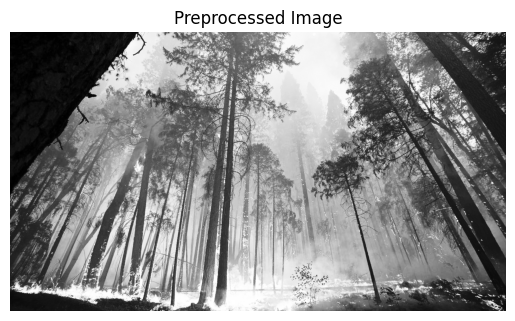

In [3]:
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread('/content/wildfire.jpg')
img2 = cv2.imread('/content/wildfire.jpg')

img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

# Noise removal
blur = cv2.GaussianBlur(gray1, (5,5), 0)

# Contrast
contrast = cv2.equalizeHist(gray1)

plt.imshow(contrast, cmap='gray')
plt.title("Preprocessed Image")
plt.axis('off')

(np.float64(-0.5), np.float64(1528.5), np.float64(859.5), np.float64(-0.5))

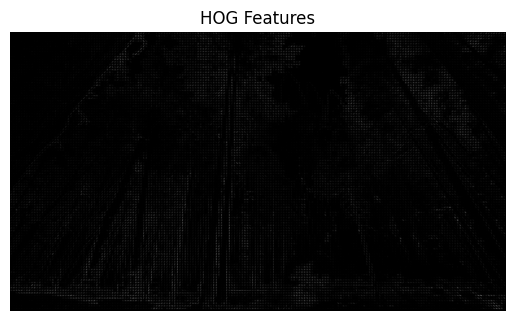

In [4]:
from skimage.feature import hog

hog_features, hog_image = hog(gray1, visualize=True)

plt.imshow(hog_image, cmap='gray')
plt.title("HOG Features")
plt.axis('off')

(np.float64(-0.5), np.float64(1528.5), np.float64(859.5), np.float64(-0.5))

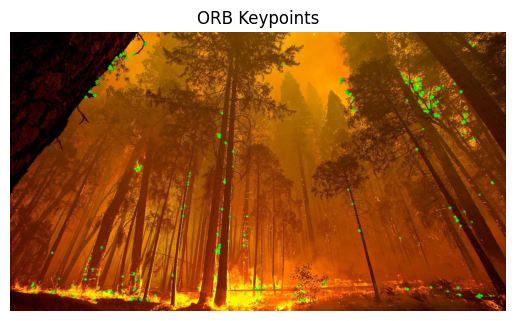

In [5]:
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(gray1, None)

img_kp = cv2.drawKeypoints(img1_rgb, kp1, None, color=(0,255,0))

plt.imshow(img_kp)
plt.title("ORB Keypoints")
plt.axis('off')

(np.float64(-0.5), np.float64(3057.5), np.float64(859.5), np.float64(-0.5))

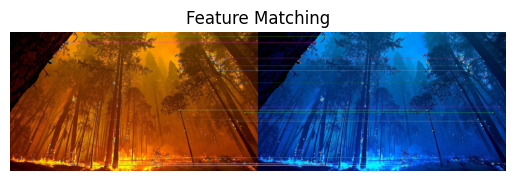

In [6]:
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
kp2, des2 = orb.detectAndCompute(gray2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

matched_img = cv2.drawMatches(img1_rgb, kp1, img2, kp2, matches[:20], None)

plt.imshow(matched_img)
plt.title("Feature Matching")
plt.axis('off')

In [7]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17898, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 17898 (delta 39), reused 9 (delta 9), pack-reused 17850 (from 5)
Receiving objects: 100% (17898/17898), 17.06 MiB | 24.26 MiB/s, done.
Resolving deltas: 100% (12193/12193), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 8.9 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
